In [41]:
# Laboratorio 5 Naive Bayes
# 
# integrantes:
# Diego Sandoval - 231977
# Jorge Gabriel Palacios Sales - 231385
# Roberto Camposeco Torres – 23968 

In [42]:
import pyreadr
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')


In [43]:
# se carga el archivo RData
result = pyreadr.read_r('listings.RData')   # ajusta la ruta si es necesario
print("Objetos en el archivo:", list(result.keys()))

# Selecciona el dataframe correcto (normalmente el primero)
df_raw = result[list(result.keys())[0]]
print(f"Dimensiones originales: {df_raw.shape}")
df_raw.head(3)

Objetos en el archivo: ['listings']
Dimensiones originales: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


In [44]:
# Elimina el símbolo $ y comas si el precio viene como string
if df_raw['price'].dtype == object:
    df_raw['price'] = (
    df_raw['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .str.strip()
)

df_raw['price'] = pd.to_numeric(df_raw['price'], errors='coerce')
# Filtrar precios atípicos (> 0 y < percentil 99)
p99 = df_raw['price'].quantile(0.99)
df = df_raw[(df_raw['price'] > 0) & (df_raw['price'] <= p99)].copy()
print(f"Filas después de limpieza: {len(df)}")
print(f"Precio – min: {df['price'].min():.2f}, max: {df['price'].max():.2f}, media: {df['price'].mean():.2f}")

Filas después de limpieza: 75531
Precio – min: 8.00, max: 20000.00, media: 347.94


In [45]:

# Ajusta esta lista según las variables que usas
FEATURES = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'number_of_reviews',
    'review_scores_rating', 'availability_365'
]

# Incluir 'room_type' si es relevante (se codificará)
if 'room_type' in df.columns:
    df = pd.get_dummies(df, columns=['room_type'], drop_first=True)
    room_cols = [c for c in df.columns if c.startswith('room_type_')]
    FEATURES += room_cols

# Asegurar que las columnas existen
FEATURES = [f for f in FEATURES if f in df.columns]
print("Features usados:", FEATURES)

# Eliminar filas con NaN en features o target
df = df[FEATURES + ['price']].dropna()
print(f"Filas finales: {len(df)}")

Features usados: ['accommodates', 'bedrooms', 'beds', 'bathrooms', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'availability_365', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']
Filas finales: 62553


In [46]:
X = df[FEATURES]
y = df['price']

SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")

Train: 50042 filas | Test: 12511 filas


In [47]:
#GaussianNB directo sobre precio continuo

N_BINS = 20
y_train_binned, bin_edges = pd.qcut(y_train, q=N_BINS, retbins=True, labels=False, duplicates='drop')
y_test_binned  = pd.cut(y_test, bins=bin_edges, labels=False, include_lowest=True)

# Medianas de cada bin (para reconvertir predicciones a precios)
bin_medians = (
    y_train.groupby(y_train_binned.values)
    .median()
    .values
)
print(f"Número de bins generados: {len(bin_medians)}")
print(f"Medianas de bins (primeros 5): {bin_medians[:5].round(2)}")

Número de bins generados: 20
Medianas de bins (primeros 5): [ 47.  72.  87.  99. 111.]


In [48]:
#  Entrenar GaussianNB 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train_binned)

y_pred_bins = gnb.predict(X_test_scaled)

y_pred_price = np.array([
    bin_medians[int(b)] if not np.isnan(b) else np.nan
    for b in y_pred_bins
])

# Filtrar pares válidos
mask = ~np.isnan(y_test_binned)
y_real_valid = y_test[mask]
y_pred_valid = y_pred_price[mask]

print(f"Predicciones válidas: {mask.sum()} de {len(mask)}")

# Muestra de predicciones vs. reales
comparison = pd.DataFrame({
    'Precio Real': y_real_valid.values[:10],
    'Precio Predicho': y_pred_valid[:10]
})
print("\nMuestra de predicciones (primeras 10):")
comparison

Predicciones válidas: 12511 de 12511

Muestra de predicciones (primeras 10):


,Precio Real,Precio Predicho
0,82.0,72.0
1,74.0,87.0
2,238.0,191.0
3,149.0,161.0
4,250.0,191.0
5,199.0,375.0
6,32.0,72.0
7,105.0,87.0
8,116.0,161.0
9,128.0,122.0


In [49]:
# punto 2
mae_nb  = mean_absolute_error(y_real_valid, y_pred_valid)
rmse_nb = np.sqrt(mean_squared_error(y_real_valid, y_pred_valid))
r2_nb   = r2_score(y_real_valid, y_pred_valid)

print("=== Métricas – Naive Bayes Regresión ===")
print(f"MAE  (Error Absoluto Medio):       ${mae_nb:.2f}")
print(f"RMSE (Raíz del Error Cuadrático):  ${rmse_nb:.2f}")
print(f"R²   (Coef. de Determinación):      {r2_nb:.4f}")

=== Métricas – Naive Bayes Regresión ===
MAE  (Error Absoluto Medio):       $155.78
RMSE (Raíz del Error Cuadrático):  $452.44
R²   (Coef. de Determinación):      0.1074


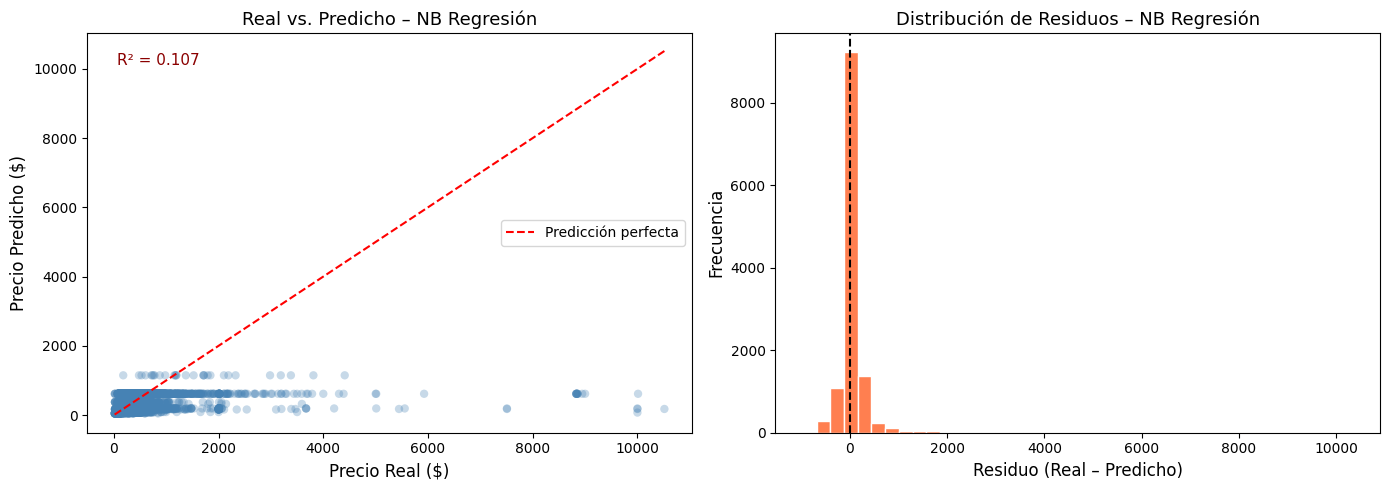

In [50]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: real vs predicho
axes[0].scatter(y_real_valid, y_pred_valid, alpha=0.3, color='steelblue', edgecolors='none')
lims = [min(y_real_valid.min(), y_pred_valid.min()),
        max(y_real_valid.max(), y_pred_valid.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Precio Real ($)', fontsize=12)
axes[0].set_ylabel('Precio Predicho ($)', fontsize=12)
axes[0].set_title('Real vs. Predicho – NB Regresión', fontsize=13)
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2_nb:.3f}', transform=axes[0].transAxes,
        fontsize=11, color='darkred')

# Distribución de residuos
residuals = y_real_valid.values - y_pred_valid
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residuo (Real – Predicho)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Residuos – NB Regresión', fontsize=13)

plt.tight_layout()
plt.show()